In [45]:
from pathlib import Path
import json
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import seaborn as sns


RUN_DIR = Path("../results/baseline_olympiad_gpt41_n50_20260609")


RESULTS_DIR = RUN_DIR / "saved_results_1shot"
OUTPUTS_DIR = RUN_DIR / "outputs"
OUTPUTS_DIR.mkdir(exist_ok=True)

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 120

In [46]:
# Load predictions and metadata
pred = pd.read_csv(RESULTS_DIR / "predictions.csv")
summary = pd.read_csv(RESULTS_DIR / "summary.csv")

with open(RUN_DIR / "parsed_traces.json") as f:
    parsed = json.load(f)

meta = pd.DataFrame([
    {"trace_id": t["metadata"]["trace_id"], "correct": t["metadata"]["correct"]}
    for t in parsed
])

df = pred.merge(meta, on="trace_id", how="left")

FM_CODES = ["1.1","1.2","1.3","1.4","1.5",
            "2.1","2.2","2.3","2.4","2.5","2.6",
            "3.1","3.2","3.3"]

FM_NAMES = {
    "1.1": "Disobey Task Specification",
    "1.2": "Disobey Role Specification",
    "1.3": "Step Repetition",
    "1.4": "Loss of Conversation History",
    "1.5": "Unaware of Termination Conditions",
    "2.1": "Conversation Reset",
    "2.2": "Fail to Ask for Clarification",
    "2.3": "Task Derailment",
    "2.4": "Information Withholding",
    "2.5": "Ignored Other Agent's Input",
    "2.6": "Action-Reasoning Mismatch",
    "3.1": "Premature Termination",
    "3.2": "No or Incorrect Verification",
    "3.3": "Weak Verification",
}

n_traces = len(df)
print(f"Loaded {n_traces} traces  |  correct: {df['correct'].sum()}  |  incorrect: {(~df['correct']).sum()}")
summary

Loaded 49 traces  |  correct: 32  |  incorrect: 17


,name,model,total_cost_usd,mean_cost_usd,total_latency_s,mean_latency_s
0,olympiad_gemini25flash_zero_shot,gemini-2.5-flash,0.0,0.0,699.631726,14.278198


In [47]:
import yaml

with open(RUN_DIR / "run_config.yaml") as _f:
    _cfg = yaml.safe_load(_f)

_counts   = df[FM_CODES].sum()
_top3     = _counts.nlargest(3)
_fm_top3  = " | ".join(
    f"{code} {FM_NAMES[code]} ({int(_top3[code])})" for code in _top3.index
)
_n_with_fm = (df[FM_CODES].sum(axis=1) > 0).sum()

_meta = pd.DataFrame([
    ("Benchmark",            _cfg["benchmark"]),
    ("Model (agent)",        _cfg["model"]["name"]),
    ("Framework",            "AG2"),
    ("n (traces)",           n_traces),
    ("Accuracy",             f"{df['correct'].mean()*100:.1f}%"),
    ("Dominant FMs (top 3)", _fm_top3),
    ("Traces with ≥1 FM", f"{_n_with_fm} / {n_traces} ({_n_with_fm/n_traces*100:.1f}%)"),
], columns=["Metric", "Value"])
_meta.style.hide(axis="index")

Metric,Value
Benchmark,olympiad
Model (agent),gpt-4.1
Framework,AG2
n (traces),49
Accuracy,65.3%
Dominant FMs (top 3),1.1 Disobey Task Specification (14) | 2.6 Action-Reasoning Mismatch (9) | 3.3 Weak Verification (9)
Traces with ≥1 FM,23 / 49 (46.9%)


## 1. Failure Mode Distribution

In [48]:
counts = df[FM_CODES].sum().astype(int)
pcts   = (counts / n_traces * 100).round(1)

dist = pd.DataFrame({
    "FM":    FM_CODES,
    "Name":  [FM_NAMES[c] for c in FM_CODES],
    "Count": counts.values,
    "%":     pcts.values,
})

dist

,FM,Name,Count,%
0,1.1,Disobey Task Specification,14,28.6
1,1.2,Disobey Role Specification,1,2.0
2,1.3,Step Repetition,4,8.2
3,1.4,Loss of Conversation History,1,2.0
4,1.5,Unaware of Termination Conditions,0,0.0
5,2.1,Conversation Reset,0,0.0
6,2.2,Fail to Ask for Clarification,3,6.1
7,2.3,Task Derailment,4,8.2
8,2.4,Information Withholding,0,0.0
9,2.5,Ignored Other Agent's Input,0,0.0


## 2. FM Prevalence Bar Chart

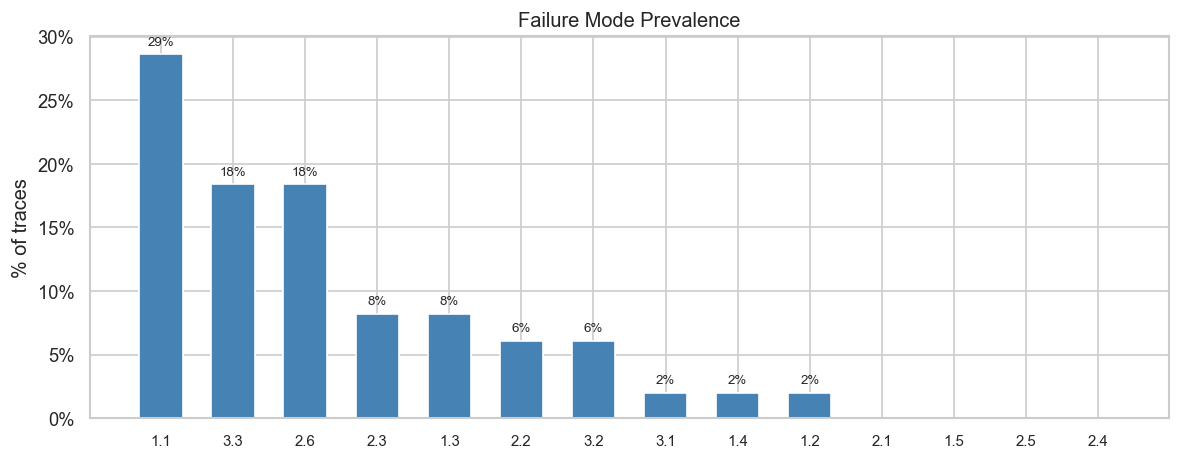

In [49]:
sorted_dist = dist.sort_values("%", ascending=False)

fig, ax = plt.subplots(figsize=(10, 4))
bars = ax.bar(range(len(sorted_dist)), sorted_dist["%"], color="steelblue", width=0.6)

ax.set_xticks(range(len(sorted_dist)))
ax.set_xticklabels(sorted_dist["FM"], fontsize=9)
ax.set_ylabel("% of traces")
ax.set_title("Failure Mode Prevalence")
ax.yaxis.set_major_formatter(mticker.PercentFormatter(decimals=0))

for bar, val in zip(bars, sorted_dist["%"]):
    if val > 0:
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
                f"{val:.0f}%", ha="center", va="bottom", fontsize=8)

fig.tight_layout()
fig.savefig(OUTPUTS_DIR / "fm_prevalence.pdf", bbox_inches="tight")
plt.show()

## 3. Accuracy vs FM Presence

In [50]:
rows = []
for code in FM_CODES:
    with_fm    = df[df[code] == 1]
    without_fm = df[df[code] == 0]
    fail_with    = (1 - with_fm["correct"]).mean()    * 100 if len(with_fm)    > 0 else float("nan")
    fail_without = (1 - without_fm["correct"]).mean() * 100 if len(without_fm) > 0 else float("nan")
    rows.append({
        "code":         code,
        "name":         FM_NAMES[code],
        "n_with":       len(with_fm),
        "fail_with":    fail_with,
        "fail_without": fail_without,
        "delta":        fail_with - fail_without,
    })

acc_df = pd.DataFrame(rows).sort_values("fail_with", ascending=False).reset_index(drop=True)
acc_df.style.format({"fail_with": "{:.1f}%", "fail_without": "{:.1f}%", "delta": "{:+.1f}pp"}, na_rep="-")

,code,name,n_with,fail_with,fail_without,delta
0,3.1,Premature Termination,1,100.0%,33.3%,+66.7pp
1,1.4,Loss of Conversation History,1,100.0%,33.3%,+66.7pp
2,1.3,Step Repetition,4,75.0%,31.1%,+43.9pp
3,1.1,Disobey Task Specification,14,57.1%,25.7%,+31.4pp
4,3.3,Weak Verification,9,55.6%,30.0%,+25.6pp
5,2.3,Task Derailment,4,50.0%,33.3%,+16.7pp
6,2.6,Action-Reasoning Mismatch,9,44.4%,32.5%,+11.9pp
7,2.2,Fail to Ask for Clarification,3,33.3%,34.8%,-1.4pp
8,3.2,No or Incorrect Verification,3,33.3%,34.8%,-1.4pp
9,1.2,Disobey Role Specification,1,0.0%,35.4%,-35.4pp


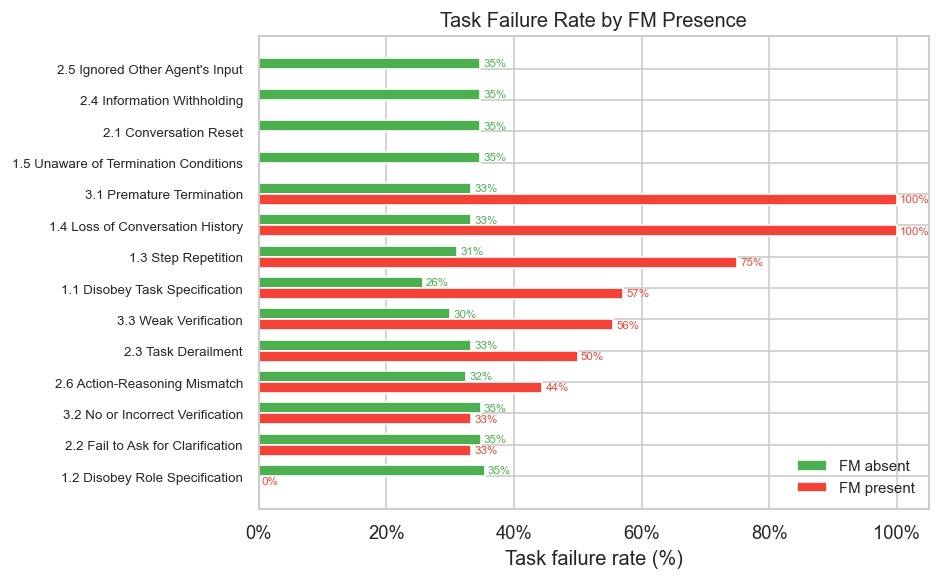

In [51]:
plot_df = acc_df.sort_values("fail_with", ascending=True).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(8, 5))

y = np.arange(len(plot_df))
h = 0.35
ylabels = [f"{r['code']} {r['name']}" for _, r in plot_df.iterrows()]

ax.barh(y + h/2, plot_df["fail_without"], h, label="FM absent",  color="#4CAF50")
ax.barh(y - h/2, plot_df["fail_with"],    h, label="FM present", color="#F44336")

ax.set_yticks(y)
ax.set_yticklabels(ylabels, fontsize=8)
ax.set_xlabel("Task failure rate (%)")
ax.set_title("Task Failure Rate by FM Presence")
ax.xaxis.set_major_formatter(mticker.PercentFormatter(decimals=0))
ax.legend(frameon=False, fontsize=9)

for i, row in plot_df.iterrows():
    if not np.isnan(row["fail_with"]):
        ax.text(row["fail_with"] + 0.5, i - h/2,
                f"{row['fail_with']:.0f}%", va="center", fontsize=7, color="#F44336")
    if not np.isnan(row["fail_without"]):
        ax.text(row["fail_without"] + 0.5, i + h/2,
                f"{row['fail_without']:.0f}%", va="center", fontsize=7, color="#4CAF50")

fig.tight_layout()
fig.savefig(OUTPUTS_DIR / "fm_accuracy.pdf", bbox_inches="tight")
plt.show()

## 4. Turn Count Distribution

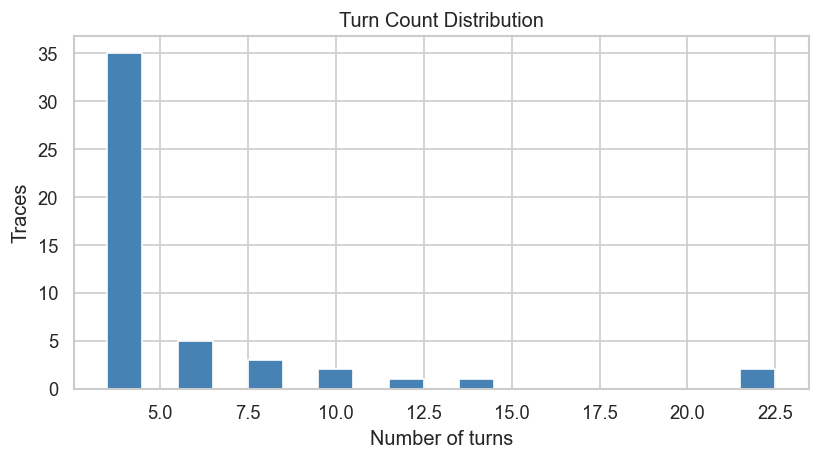

In [52]:
_turns = [t["metadata"]["n_turns"] for t in parsed]

fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(_turns, bins=range(min(_turns), max(_turns) + 2),
        color="steelblue", edgecolor="white", align="left")
ax.set_xlabel("Number of turns")
ax.set_ylabel("Traces")
ax.set_title("Turn Count Distribution")
fig.tight_layout()
fig.savefig(OUTPUTS_DIR / "turn_count_distribution.pdf", bbox_inches="tight")
plt.show()

## 5. Token Count per Trace

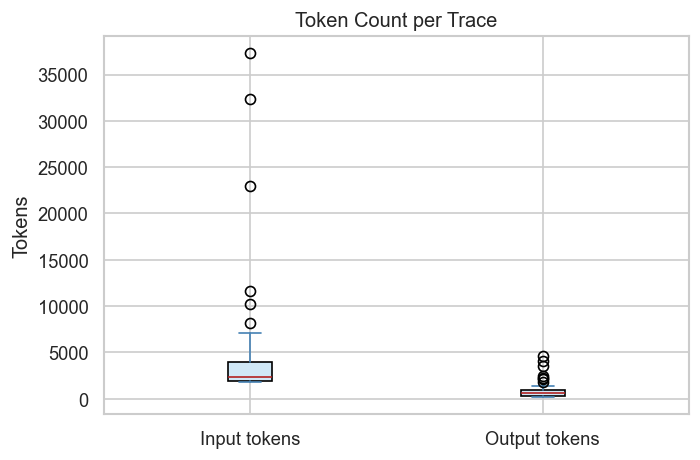

In [53]:
_token_df = pd.DataFrame([
    {"Input tokens":  t["metadata"]["input_tokens"],
     "Output tokens": t["metadata"]["output_tokens"]}
    for t in parsed
])

fig, ax = plt.subplots(figsize=(6, 4))
_token_df.plot.box(ax=ax,
    color={"boxes": "steelblue", "whiskers": "steelblue",
           "medians": "firebrick", "caps": "steelblue"},
    patch_artist=True,
    boxprops=dict(facecolor="#D0E8F7"))
ax.set_ylabel("Tokens")
ax.set_title("Token Count per Trace")
fig.tight_layout()
fig.savefig(OUTPUTS_DIR / "token_count_per_trace.pdf", bbox_inches="tight")
plt.show()